# LOR Demographic Context and Priority Classification

## Imports

In [ ]:
from scipy.stats import spearmanr
import matplotlib.pyplot as plt
from google.colab import drive
from pathlib import Path
import pandas as pd
import numpy as np



try:
    import geopandas as gpd
except ImportError:
    !pip install geopandas -q
    import geopandas as gpd

drive.mount('/content/drive', force_remount=True)

BASE_DIR = Path('/content/drive/MyDrive/SmartCities')
FIG_DIR = BASE_DIR / "final_figures"
TABLE_DIR = BASE_DIR / "final_tables"

FIG_DIR.mkdir(exist_ok=True)
TABLE_DIR.mkdir(exist_ok=True)

demographic_file = BASE_DIR / 'EWR_L21_202412E_Matrix.csv'
lor_file = BASE_DIR / 'lor_planungsraeume_2021.geojson'
processed_file = BASE_DIR / 'berlin_pedestrians_2020_2024.csv'

print("BASE_DIR exists:", BASE_DIR.exists())
print("Demographic file exists:", demographic_file.exists())
print("LOR file exists:", lor_file.exists())
print("Processed accident file exists:", processed_file.exists())

Mounted at /content/drive
BASE_DIR exists: True
Demographic file exists: True
LOR file exists: True
Processed accident file exists: True


In [ ]:
# Read demographic data
dem = pd.read_csv(
    demographic_file,
    sep=';',
    encoding='utf-8-sig',
    dtype={
        'RAUMID': str,
        'BEZ': str,
        'PGR': str,
        'BZR': str,
        'PLR': str,
        'BEZPGR': str
    }
)

# Read LOR Planungsraum boundaries
lor = gpd.read_file(lor_file)

# If CRS is missing, set it manually.
# The LOR file uses ETRS89 / UTM zone 33N.
if lor.crs is None:
    lor = lor.set_crs('EPSG:25833')

print("Demographic data shape:", dem.shape)
print("LOR boundary data shape:", lor.shape)
print("LOR CRS:", lor.crs)

print("\nDemographic columns:")
print(dem.columns.tolist())

print("\nLOR columns:")
print(lor.columns.tolist())

Demographic data shape: (542, 51)
LOR boundary data shape: (542, 6)
LOR CRS: EPSG:25833

Demographic columns:
['ZEIT', 'RAUMID', 'BEZ', 'PGR', 'BZR', 'PLR', 'BEZPGR', 'E_E', 'E_EM', 'E_EW', 'E_E00_01', 'E_E01_02', 'E_E02_03', 'E_E03_05', 'E_E05_06', 'E_E06_07', 'E_E07_08', 'E_E08_10', 'E_E10_12', 'E_E12_14', 'E_E14_15', 'E_E15_18', 'E_E18_21', 'E_E21_25', 'E_E25_27', 'E_E27_30', 'E_E30_35', 'E_E35_40', 'E_E40_45', 'E_E45_50', 'E_E50_55', 'E_E55_60', 'E_E60_63', 'E_E63_65', 'E_E65_67', 'E_E67_70', 'E_E70_75', 'E_E75_80', 'E_E80_85', 'E_E85_90', 'E_E90_95', 'E_E95_110', 'E_EU1', 'E_E1U6', 'E_E6U15', 'E_E15U18', 'E_E18U25', 'E_E25U55', 'E_E55U65', 'E_E65U80', 'E_E80U110']

LOR columns:
['PLR_ID', 'PLR_NAME', 'BEZ', 'STAND', 'GROESSE_M2', 'geometry']


In [ ]:
# Make sure IDs match correctly
dem['RAUMID'] = dem['RAUMID'].astype(str).str.zfill(8)
lor['PLR_ID'] = lor['PLR_ID'].astype(str).str.zfill(8)
lor['BEZ'] = lor['BEZ'].astype(str).str.zfill(2)

# Convert demographic numeric columns
numeric_cols = [col for col in dem.columns if col.startswith('E_')]

for col in numeric_cols:
    dem[col] = pd.to_numeric(dem[col], errors='coerce')

# Main population indicators
dem['population_total'] = dem['E_E']
dem['male_population'] = dem['E_EM']
dem['female_population'] = dem['E_EW']

# Age-group indicators
dem['children_0_17'] = (
    dem['E_EU1'] +
    dem['E_E1U6'] +
    dem['E_E6U15'] +
    dem['E_E15U18']
)

dem['young_adults_18_25'] = dem['E_E18U25']
dem['working_age_25_65'] = dem['E_E25U55'] + dem['E_E55U65']
dem['elderly_65_plus'] = dem['E_E65U80'] + dem['E_E80U110']

# Demographic shares
dem['female_share'] = dem['female_population'] / dem['population_total']
dem['male_share'] = dem['male_population'] / dem['population_total']
dem['children_share'] = dem['children_0_17'] / dem['population_total']
dem['young_adults_share'] = dem['young_adults_18_25'] / dem['population_total']
dem['working_age_share'] = dem['working_age_25_65'] / dem['population_total']
dem['elderly_share'] = dem['elderly_65_plus'] / dem['population_total']

# Keeping the variables needed for the analysis
dem_context = dem[[
    'RAUMID',
    'population_total',
    'male_population',
    'female_population',
    'children_0_17',
    'young_adults_18_25',
    'working_age_25_65',
    'elderly_65_plus',
    'female_share',
    'male_share',
    'children_share',
    'young_adults_share',
    'working_age_share',
    'elderly_share'
]].copy()

print("Demographic indicators created:")
display(dem_context.head())

Demographic indicators created:


,RAUMID,population_total,male_population,female_population,children_0_17,young_adults_18_25,working_age_25_65,elderly_65_plus,female_share,male_share,children_share,young_adults_share,working_age_share,elderly_share
0,01100101,3580.0,1869.0,1711.0,417.0,296.0,2150.0,717.0,0.477933,0.522067,0.116480,0.082682,0.600559,0.200279
1,01100102,2034.0,1113.0,921.0,223.0,144.0,1405.0,262.0,0.452802,0.547198,0.109636,0.070796,0.690757,0.128810
2,01100103,5790.0,3073.0,2717.0,784.0,422.0,3486.0,1098.0,0.469257,0.530743,0.135406,0.072884,0.602073,0.189637
3,01100104,4889.0,2587.0,2302.0,739.0,464.0,3237.0,449.0,0.470853,0.529147,0.151156,0.094907,0.662099,0.091839
4,01100205,2917.0,1545.0,1372.0,322.0,238.0,1866.0,491.0,0.470346,0.529654,0.110387,0.081591,0.639698,0.168324


In [ ]:
processed_file = BASE_DIR / 'berlin_pedestrians_2020_2024.csv'

df = pd.read_csv(processed_file)

print("Accident dataset loaded:", df.shape)
print(df['YEAR'].value_counts().sort_index())

Accident dataset loaded: (7931, 24)
YEAR
2020    1396
2021    1460
2022    1569
2023    1794
2024    1712
Name: count, dtype: int64


In [ ]:
acc_lor = df.copy()

# Function to clean coordinate columns
def to_numeric_coord(series):
    return (
        series.astype(str)
        .str.replace(',', '.', regex=False)
        .str.strip()
        .str.rstrip('.')
        .replace('nan', np.nan)
        .astype(float)
    )

# Convert coordinates to numeric
acc_lor['XGCSWGS84'] = to_numeric_coord(acc_lor['XGCSWGS84'])
acc_lor['YGCSWGS84'] = to_numeric_coord(acc_lor['YGCSWGS84'])

# Remove rows without valid coordinates
acc_lor = acc_lor.dropna(subset=['XGCSWGS84', 'YGCSWGS84']).copy()

# Create binary severity indicator:
# 1 = fatal or serious injury
# 0 = slight/minor injury
if 'Severe_Binary' not in acc_lor.columns:
    acc_lor['Severe_Binary'] = acc_lor['UKATEGORIE'].apply(lambda x: 1 if x in [1, 2] else 0)

# Create GeoDataFrame from accident coordinates
acc_gdf = gpd.GeoDataFrame(
    acc_lor,
    geometry=gpd.points_from_xy(acc_lor['XGCSWGS84'], acc_lor['YGCSWGS84']),
    crs='EPSG:4326'
)

# Convert accident points to the same CRS as LOR polygons
acc_gdf = acc_gdf.to_crs(lor.crs)

# Keep only the needed LOR columns
lor_small = lor[['PLR_ID', 'PLR_NAME', 'BEZ', 'GROESSE_M2', 'geometry']].copy()

# Spatial join: assign every accident point to a LOR Planungsraum
acc_lor_joined = gpd.sjoin(
    acc_gdf,
    lor_small,
    how='left',
    predicate='within'
)

print("Accidents assigned to a LOR area:", acc_lor_joined['PLR_ID'].notna().sum())
print("Accidents without LOR assignment:", acc_lor_joined['PLR_ID'].isna().sum())

display(acc_lor_joined[['YEAR', 'UKATEGORIE', 'PLR_ID', 'PLR_NAME', 'BEZ']].head())

Accidents assigned to a LOR area: 7930
Accidents without LOR assignment: 1


,YEAR,UKATEGORIE,PLR_ID,PLR_NAME,BEZ
0,2021,3,07501134,Hundsteinweg,07
1,2021,3,02200208,Rathaus Yorckstraße,02
2,2021,3,07200307,Bayerischer Platz,07
3,2021,3,07100101,Wittenbergplatz,07
4,2021,3,07300516,Odenwaldstraße,07


In [ ]:
accidents_by_lor = (
    acc_lor_joined
    .dropna(subset=['PLR_ID'])
    .groupby('PLR_ID')
    .agg(
        total_accidents=('UKATEGORIE', 'count'),
        severe_accidents=('Severe_Binary', 'sum'),
        fatal_accidents=('UKATEGORIE', lambda x: (x == 1).sum()),
        serious_accidents=('UKATEGORIE', lambda x: (x == 2).sum()),
        minor_accidents=('UKATEGORIE', lambda x: (x == 3).sum()),
        dark_accidents=('ULICHTVERH', lambda x: (x == 2).sum()),
        car_accidents=('IstPKW', 'sum'),
        bicycle_accidents=('IstRad', 'sum'),
        motorcycle_accidents=('IstKrad', 'sum'),
        heavy_vehicle_accidents=('IstGkfz', 'sum'),
        other_mode_accidents=('IstSonstige', 'sum')
    )
    .reset_index()
)

# Calculate accident-condition shares
accidents_by_lor['severe_rate'] = accidents_by_lor['severe_accidents'] / accidents_by_lor['total_accidents']
accidents_by_lor['dark_share'] = accidents_by_lor['dark_accidents'] / accidents_by_lor['total_accidents']
accidents_by_lor['car_share'] = accidents_by_lor['car_accidents'] / accidents_by_lor['total_accidents']
accidents_by_lor['bicycle_share'] = accidents_by_lor['bicycle_accidents'] / accidents_by_lor['total_accidents']
accidents_by_lor['heavy_vehicle_share'] = accidents_by_lor['heavy_vehicle_accidents'] / accidents_by_lor['total_accidents']

print("Top LOR areas by total pedestrian accidents:")
display(accidents_by_lor.sort_values('total_accidents', ascending=False).head(10))

Top LOR areas by total pedestrian accidents:


,PLR_ID,total_accidents,severe_accidents,fatal_accidents,serious_accidents,minor_accidents,dark_accidents,car_accidents,bicycle_accidents,motorcycle_accidents,heavy_vehicle_accidents,other_mode_accidents,severe_rate,dark_share,car_share,bicycle_share,heavy_vehicle_share
9,01100310,93,23,0,23,70,28,41,23,3,1,26,0.247312,0.301075,0.440860,0.247312,0.010753
32,01300733,84,17,0,17,67,25,50,21,6,1,8,0.202381,0.297619,0.595238,0.250000,0.011905
8,01100309,83,14,0,14,69,23,41,27,5,1,12,0.168675,0.277108,0.493976,0.325301,0.012048
210,05100316,75,17,2,15,58,21,53,8,0,0,16,0.226667,0.280000,0.706667,0.106667,0.000000
184,04501042,74,8,0,8,66,28,45,12,4,0,14,0.108108,0.378378,0.608108,0.162162,0.000000
7,01100308,67,18,0,18,49,19,34,19,3,0,13,0.268657,0.283582,0.507463,0.283582,0.000000
5,01100206,66,15,0,15,51,18,24,25,2,0,15,0.227273,0.272727,0.363636,0.378788,0.000000
35,01300836,63,10,2,8,53,27,43,8,2,2,9,0.158730,0.428571,0.682540,0.126984,0.031746
500,12200309,62,16,1,15,46,10,45,10,2,1,5,0.258065,0.161290,0.725806,0.161290,0.016129
221,05200629,58,16,0,16,42,13,37,6,3,0,12,0.275862,0.224138,0.637931,0.103448,0.000000


## Merging Accident and Demographic Context

In [ ]:
lor_demo = lor_small.merge(
    dem_context,
    left_on='PLR_ID',
    right_on='RAUMID',
    how='left'
)

# Merge accident indicators
lor_analysis = lor_demo.merge(
    accidents_by_lor,
    on='PLR_ID',
    how='left'
)

# Fill missing accident counts with zero
accident_count_cols = [
    'total_accidents',
    'severe_accidents',
    'fatal_accidents',
    'serious_accidents',
    'minor_accidents',
    'dark_accidents',
    'car_accidents',
    'bicycle_accidents',
    'motorcycle_accidents',
    'heavy_vehicle_accidents',
    'other_mode_accidents'
]

for col in accident_count_cols:
    lor_analysis[col] = lor_analysis[col].fillna(0).astype(int)

# Recalculate shares after filling missing accident counts
lor_analysis['severe_rate'] = lor_analysis['severe_accidents'] / lor_analysis['total_accidents'].replace(0, np.nan)
lor_analysis['dark_share'] = lor_analysis['dark_accidents'] / lor_analysis['total_accidents'].replace(0, np.nan)
lor_analysis['car_share'] = lor_analysis['car_accidents'] / lor_analysis['total_accidents'].replace(0, np.nan)
lor_analysis['bicycle_share'] = lor_analysis['bicycle_accidents'] / lor_analysis['total_accidents'].replace(0, np.nan)
lor_analysis['heavy_vehicle_share'] = lor_analysis['heavy_vehicle_accidents'] / lor_analysis['total_accidents'].replace(0, np.nan)

# Calculate area and population density
lor_analysis['area_km2'] = lor_analysis['GROESSE_M2'] / 1_000_000
lor_analysis['population_density'] = lor_analysis['population_total'] / lor_analysis['area_km2']

# Calculate accident rates per 10,000 residents
lor_analysis['accidents_per_10k_residents'] = (
    lor_analysis['total_accidents'] / lor_analysis['population_total'] * 10000
)

lor_analysis['severe_accidents_per_10k_residents'] = (
    lor_analysis['severe_accidents'] / lor_analysis['population_total'] * 10000
)

# Add borough names
borough_map = {
    '01': 'Mitte',
    '02': 'Friedrichshain-Kreuzberg',
    '03': 'Pankow',
    '04': 'Charlottenburg-Wilmersdorf',
    '05': 'Spandau',
    '06': 'Steglitz-Zehlendorf',
    '07': 'Tempelhof-Schöneberg',
    '08': 'Neukölln',
    '09': 'Treptow-Köpenick',
    '10': 'Marzahn-Hellersdorf',
    '11': 'Lichtenberg',
    '12': 'Reinickendorf'
}

lor_analysis['borough_name'] = lor_analysis['BEZ'].map(borough_map)

print("Final LOR contextual dataset:", lor_analysis.shape)
print("LOR areas without population data:", lor_analysis['population_total'].isna().sum())

display(lor_analysis.head())

Final LOR contextual dataset: (542, 40)
LOR areas without population data: 2


,PLR_ID,PLR_NAME,BEZ,GROESSE_M2,geometry,RAUMID,population_total,male_population,female_population,children_0_17,...,severe_rate,dark_share,car_share,bicycle_share,heavy_vehicle_share,area_km2,population_density,accidents_per_10k_residents,severe_accidents_per_10k_residents,borough_name
0,11501341,Karlshorst Süd,11,2294021.723,"MULTIPOLYGON (((400826.929 5814871.126, 400825...",11501341,10103.0,4988.0,5115.0,2330.0,...,0.416667,0.166667,0.500000,0.416667,0.0,2.294022,4404.055942,11.877660,4.949025,Lichtenberg
1,07601340,Tirschenreuther Ring Ost,07,413969.326,"MULTIPOLYGON (((387795.701 5807587.153, 387789...",07601340,6416.0,3043.0,3373.0,1120.0,...,0.230769,0.153846,0.769231,0.076923,0.0,0.413969,15498.732870,20.261845,4.675810,Tempelhof-Schöneberg
2,02500831,Wismarplatz,02,248988.291,"MULTIPOLYGON (((396010.552 5819339.57, 396021....",02500831,7857.0,4074.0,3783.0,1092.0,...,0.166667,0.250000,0.833333,0.166667,0.0,0.248988,31555.700746,15.273005,2.545501,Friedrichshain-Kreuzberg
3,12601134,Märkisches Zentrum,12,1127855.841,"MULTIPOLYGON (((387367.428 5828619.763, 387315...",12601134,16006.0,7699.0,8307.0,3601.0,...,0.555556,0.222222,0.888889,0.000000,0.0,1.127856,14191.529997,5.622891,3.123829,Reinickendorf
4,07601547,Horstwalder Straße,07,941433.954,"MULTIPOLYGON (((391807.174 5805331.9, 391808.1...",07601547,3828.0,1830.0,1998.0,699.0,...,0.375000,0.000000,0.750000,0.250000,0.0,0.941434,4066.137602,20.898642,7.836991,Tempelhof-Schöneberg


In [ ]:
top_lor_count = (
    lor_analysis
    .sort_values('total_accidents', ascending=False)
    [[
        'PLR_ID',
        'PLR_NAME',
        'borough_name',
        'total_accidents',
        'severe_accidents',
        'severe_rate',
        'population_total',
        'population_density',
        'accidents_per_10k_residents',
        'children_share',
        'elderly_share',
        'female_share'
    ]]
    .head(10)
    .copy()
)

# Convert shares to percentages
for col in ['severe_rate', 'children_share', 'elderly_share', 'female_share']:
    top_lor_count[col] = (top_lor_count[col] * 100).round(2)

top_lor_count['accidents_per_10k_residents'] = top_lor_count['accidents_per_10k_residents'].round(2)
top_lor_count['population_density'] = top_lor_count['population_density'].round(0)

print("Top 10 LOR areas by total pedestrian accidents:")
display(top_lor_count)

top_lor_count.to_csv('top_10_lor_by_accident_count.csv', index=False)

Top 10 LOR areas by total pedestrian accidents:


,PLR_ID,PLR_NAME,borough_name,total_accidents,severe_accidents,severe_rate,population_total,population_density,accidents_per_10k_residents,children_share,elderly_share,female_share
424,01100310,Alexanderplatzviertel,Mitte,93,23,24.73,10181.0,7457.0,91.35,12.03,14.59,47.19
336,01300733,Gesundbrunnen,Mitte,84,17,20.24,11684.0,17749.0,71.89,17.17,11.17,48.38
334,01100309,Oranienburger Straße,Mitte,83,14,16.87,12651.0,12509.0,65.61,14.21,9.60,49.01
487,05100316,Carl-Schurz-Straße,Spandau,75,17,22.67,10505.0,7626.0,71.39,16.33,16.88,50.79
530,04501042,Breitscheidplatz,Charlottenburg-Wilmersdorf,74,8,10.81,3664.0,6069.0,201.97,14.44,20.66,49.59
450,01100308,Charitéviertel,Mitte,67,18,26.87,7297.0,4337.0,91.82,13.14,10.15,48.91
446,01100206,Unter den Linden,Mitte,66,15,22.73,1876.0,1446.0,351.81,12.69,13.27,48.13
308,01300836,Humboldthain Nordwest,Mitte,63,10,15.87,14947.0,10370.0,42.15,16.92,10.02,47.32
413,12200309,Scharnweberstraße,Reinickendorf,62,16,25.81,11286.0,15947.0,54.94,16.57,15.75,48.39
140,05200629,Borkumer Straße,Spandau,58,16,27.59,8357.0,6304.0,69.40,15.97,22.53,50.81


In [ ]:
# Exclude very small residential populations to avoid unstable rates
lor_rate_base = lor_analysis[
    (lor_analysis['population_total'] >= 1000) &
    (lor_analysis['total_accidents'] > 0)
].copy()

top_lor_rate = (
    lor_rate_base
    .sort_values('accidents_per_10k_residents', ascending=False)
    [[
        'PLR_ID',
        'PLR_NAME',
        'borough_name',
        'total_accidents',
        'severe_accidents',
        'population_total',
        'accidents_per_10k_residents',
        'severe_accidents_per_10k_residents',
        'children_share',
        'elderly_share',
        'female_share',
        'population_density'
    ]]
    .head(10)
    .copy()
)

for col in ['children_share', 'elderly_share', 'female_share']:
    top_lor_rate[col] = (top_lor_rate[col] * 100).round(2)

top_lor_rate['accidents_per_10k_residents'] = top_lor_rate['accidents_per_10k_residents'].round(2)
top_lor_rate['severe_accidents_per_10k_residents'] = top_lor_rate['severe_accidents_per_10k_residents'].round(2)
top_lor_rate['population_density'] = top_lor_rate['population_density'].round(0)

print("Top 10 LOR areas by pedestrian accidents per 10,000 residents:")
display(top_lor_rate)

top_lor_rate.to_csv('top_10_lor_by_accident_rate.csv', index=False)

Top 10 LOR areas by pedestrian accidents per 10,000 residents:


,PLR_ID,PLR_NAME,borough_name,total_accidents,severe_accidents,population_total,accidents_per_10k_residents,severe_accidents_per_10k_residents,children_share,elderly_share,female_share,population_density
233,02400625,Wriezener Bahnhof,Friedrichshain-Kreuzberg,47,8,1328.0,353.92,60.24,12.50,2.48,45.63,1536.0
446,01100206,Unter den Linden,Mitte,66,15,1876.0,351.81,79.96,12.69,13.27,48.13,1446.0
228,01100102,Großer Tiergarten,Mitte,46,8,2034.0,226.16,39.33,10.96,12.88,45.28,516.0
530,04501042,Breitscheidplatz,Charlottenburg-Wilmersdorf,74,8,3664.0,201.97,21.83,14.44,20.66,49.59,6069.0
268,01200628,Lüneburger Straße,Mitte,42,5,3281.0,128.01,15.24,13.01,14.93,48.06,4400.0
459,01100205,Wilhelmstraße,Mitte,37,6,2917.0,126.84,20.57,11.04,16.83,47.03,4596.0
439,10200421,Helle Mitte,Marzahn-Hellersdorf,18,6,1757.0,102.45,34.15,18.61,13.55,50.26,10723.0
450,01100308,Charitéviertel,Mitte,67,18,7297.0,91.82,24.67,13.14,10.15,48.91,4337.0
424,01100310,Alexanderplatzviertel,Mitte,93,23,10181.0,91.35,22.59,12.03,14.59,47.19,7457.0
336,01300733,Gesundbrunnen,Mitte,84,17,11684.0,71.89,14.55,17.17,11.17,48.38,17749.0


## Top accident-count LOR areas

In [ ]:
top_lor_ids = top_lor_count['PLR_ID'].tolist()
lor_analysis['is_top_accident_lor'] = lor_analysis['PLR_ID'].isin(top_lor_ids)

def weighted_group_profile(data, label):
    total_pop = data['population_total'].sum()

    return {
        'group': label,
        'number_of_lors': len(data),
        'total_population': total_pop,
        'total_accidents': data['total_accidents'].sum(),
        'severe_accidents': data['severe_accidents'].sum(),
        'accidents_per_10k_residents': round(data['total_accidents'].sum() / total_pop * 10000, 2),
        'severe_per_10k_residents': round(data['severe_accidents'].sum() / total_pop * 10000, 2),
        'children_share_percent': round(data['children_0_17'].sum() / total_pop * 100, 2),
        'elderly_share_percent': round(data['elderly_65_plus'].sum() / total_pop * 100, 2),
        'female_share_percent': round(data['female_population'].sum() / total_pop * 100, 2),
        'average_population_density': round(data['population_density'].mean(), 0)
    }

profile_table = pd.DataFrame([
    weighted_group_profile(
        lor_analysis[lor_analysis['is_top_accident_lor']],
        'Top 10 LOR areas by accident count'
    ),
    weighted_group_profile(
        lor_analysis[~lor_analysis['is_top_accident_lor']],
        'All other LOR areas'
    )
])

print("Demographic profile of top accident LOR areas vs all other LOR areas:")
display(profile_table)

profile_table.to_csv('top_lor_vs_other_lor_demographic_profile.csv', index=False)

Demographic profile of top accident LOR areas vs all other LOR areas:


,group,number_of_lors,total_population,total_accidents,severe_accidents,accidents_per_10k_residents,severe_per_10k_residents,children_share_percent,elderly_share_percent,female_share_percent,average_population_density
0,Top 10 LOR areas by accident count,10,92448.0,725,154,78.42,16.66,15.36,13.72,48.74,8981.0
1,All other LOR areas,532,3804697.0,7205,1742,18.94,4.58,16.29,19.07,50.50,10018.0


In [ ]:
demographic_variables = [
    'population_total',
    'population_density',
    'children_share',
    'elderly_share',
    'female_share',
    'young_adults_share',
    'working_age_share'
]

accident_indicators = [
    'total_accidents',
    'severe_accidents',
    'accidents_per_10k_residents',
    'severe_accidents_per_10k_residents'
]

correlation_results = []

for accident_indicator in accident_indicators:
    for demographic_variable in demographic_variables:
        temp = (
            lor_analysis[[accident_indicator, demographic_variable]]
            .replace([np.inf, -np.inf], np.nan)
            .dropna()
        )

        if len(temp) > 2:
            corr, p_value = spearmanr(
                temp[demographic_variable],
                temp[accident_indicator]
            )

            correlation_results.append({
                'accident_indicator': accident_indicator,
                'demographic_variable': demographic_variable,
                'spearman_correlation': round(corr, 3),
                'p_value': round(p_value, 4)
            })

correlation_table = pd.DataFrame(correlation_results)

print("Spearman correlations between demographic context and accident indicators:")
display(
    correlation_table.sort_values(
        ['accident_indicator', 'spearman_correlation'],
        ascending=[True, False]
    )
)

correlation_table.to_csv('lor_demographic_correlation_results.csv', index=False)

Spearman correlations between demographic context and accident indicators:


,accident_indicator,demographic_variable,spearman_correlation,p_value
20,accidents_per_10k_residents,working_age_share,0.201,0.0000
19,accidents_per_10k_residents,young_adults_share,0.099,0.0217
15,accidents_per_10k_residents,population_density,0.017,0.6926
14,accidents_per_10k_residents,population_total,-0.028,0.5232
17,accidents_per_10k_residents,elderly_share,-0.157,0.0003
18,accidents_per_10k_residents,female_share,-0.195,0.0000
16,accidents_per_10k_residents,children_share,-0.196,0.0000
7,severe_accidents,population_total,0.375,0.0000
12,severe_accidents,young_adults_share,0.151,0.0004
8,severe_accidents,population_density,0.081,0.0608


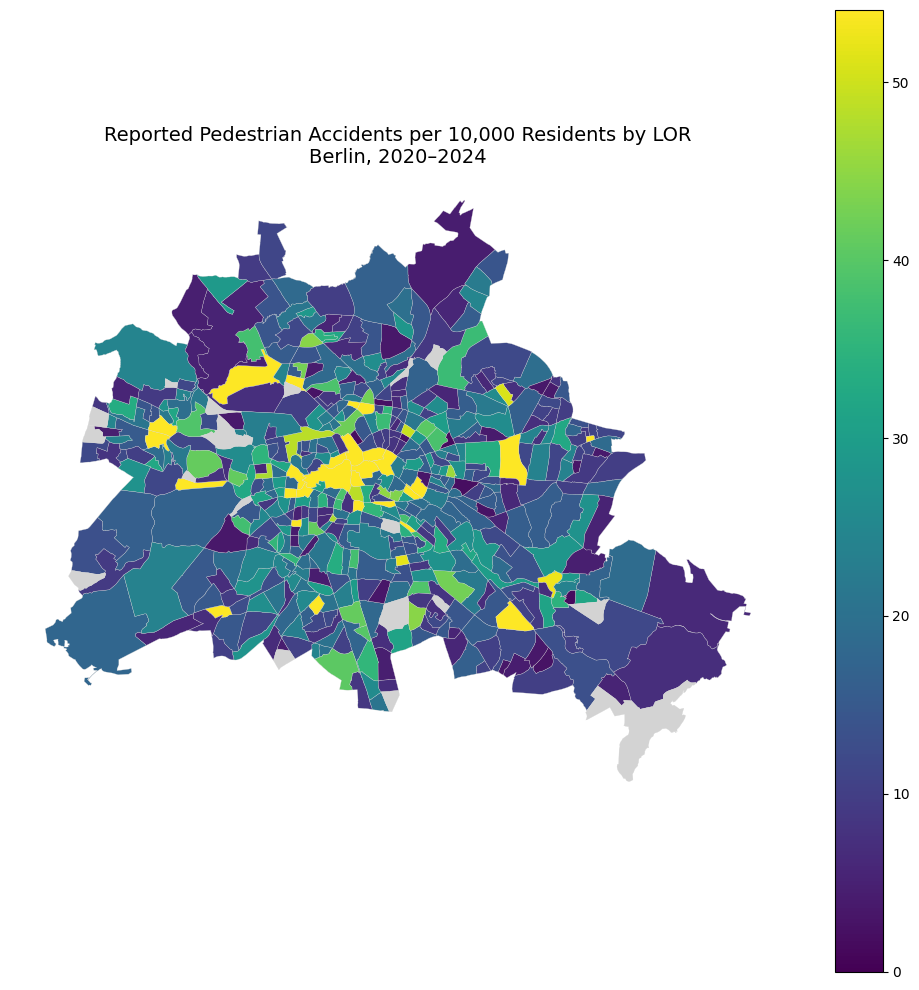

Saved map_lor_accidents_per_10k_residents_stable.png


In [ ]:
MIN_POPULATION = 1000

lor_analysis['accidents_per_10k_stable'] = np.where(
    (lor_analysis['population_total'] >= MIN_POPULATION) &
    (lor_analysis['total_accidents'] > 0),
    lor_analysis['accidents_per_10k_residents'],
    np.nan
)

# Cap the color scale at the 95th percentile to reduce the effect of extreme outliers
vmax_value = lor_analysis['accidents_per_10k_stable'].quantile(0.95)

fig, ax = plt.subplots(figsize=(10, 10))

lor_analysis.plot(
    column='accidents_per_10k_stable',
    ax=ax,
    legend=True,
    edgecolor='lightgrey',
    linewidth=0.2,
    vmin=0,
    vmax=vmax_value,
    missing_kwds={
        "color": "lightgrey",
        "label": "No accidents or population below threshold"
    }
)

ax.set_title(
    'Reported Pedestrian Accidents per 10,000 Residents by LOR\nBerlin, 2020–2024',
    fontsize=14
)

ax.set_axis_off()
plt.tight_layout()
plt.savefig('map_lor_accidents_per_10k_residents_stable.png', dpi=150)
plt.show()

print("Saved map_lor_accidents_per_10k_residents_stable.png")

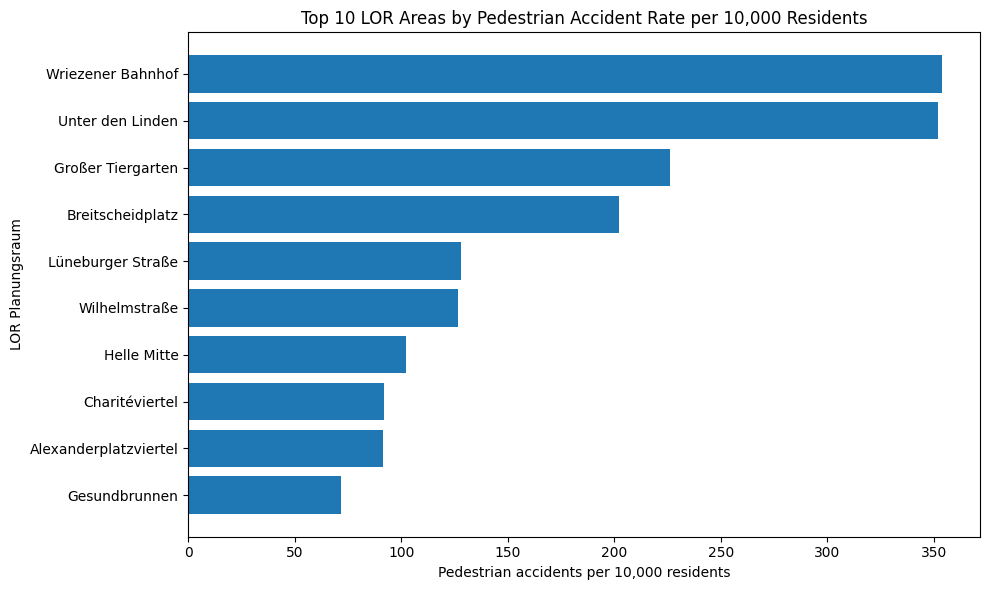

Saved chart_top_10_lor_accident_rate.png


In [ ]:
plot_data = top_lor_rate.sort_values('accidents_per_10k_residents', ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(plot_data['PLR_NAME'], plot_data['accidents_per_10k_residents'])

plt.xlabel('Pedestrian accidents per 10,000 residents')
plt.ylabel('LOR Planungsraum')
plt.title('Top 10 LOR Areas by Pedestrian Accident Rate per 10,000 Residents')
plt.tight_layout()
plt.savefig('chart_top_10_lor_accident_rate.png', dpi=150)
plt.show()

print("Saved chart_top_10_lor_accident_rate.png")

In [ ]:
# Save spatial output
lor_analysis.to_file(
    'lor_accident_demographic_context.geojson',
    driver='GeoJSON'
)

# Save table output
lor_analysis.drop(columns='geometry').to_csv(
    'lor_accident_demographic_context.csv',
    index=False
)

print("Saved lor_accident_demographic_context.geojson")
print("Saved lor_accident_demographic_context.csv")

Saved lor_accident_demographic_context.geojson
Saved lor_accident_demographic_context.csv


## Hotspot Priority Classification

In [ ]:
# Make a copy of the LOR analysis dataset
priority_df = lor_analysis.copy()

# Use only LORs with valid population and at least one accident for threshold calculation
# A minimum population threshold avoids unstable rates in very small residential areas.
MIN_POPULATION = 1000
MIN_ACCIDENTS_FOR_RATE = 5

threshold_base = priority_df[
    (priority_df['population_total'] >= MIN_POPULATION) &
    (priority_df['total_accidents'] > 0)
].copy()

# Threshold 1: high accident count = top 10% of LORs by total pedestrian accidents
high_count_threshold = threshold_base['total_accidents'].quantile(0.90)

# Threshold 2a: high severe count = top 10% of LORs by serious/fatal accident count
high_severe_count_threshold = threshold_base['severe_accidents'].quantile(0.90)

# Threshold 2b: high severity rate = top 25% of LORs by serious/fatal share
# Only calculate this for LORs with enough accidents to avoid unstable percentages.
severity_rate_base = threshold_base[
    threshold_base['total_accidents'] >= MIN_ACCIDENTS_FOR_RATE
].copy()

high_severity_rate_threshold = severity_rate_base['severe_rate'].quantile(0.75)

print("High accident count threshold:", high_count_threshold)
print("High severe accident count threshold:", high_severe_count_threshold)
print("High severity rate threshold:", round(high_severity_rate_threshold, 3))

# Create binary indicators
priority_df['high_accident_count'] = (
    (priority_df['population_total'] >= MIN_POPULATION) &
    (priority_df['total_accidents'] >= high_count_threshold)
)

priority_df['high_severity_burden'] = (
    (priority_df['population_total'] >= MIN_POPULATION) &
    (
        (priority_df['severe_accidents'] >= high_severe_count_threshold) |
        (
            (priority_df['total_accidents'] >= MIN_ACCIDENTS_FOR_RATE) &
            (priority_df['severe_rate'] >= high_severity_rate_threshold)
        )
    )
)

# Assign priority classes
conditions = [
    priority_df['high_accident_count'] & priority_df['high_severity_burden'],
    priority_df['high_accident_count'] & ~priority_df['high_severity_burden'],
    ~priority_df['high_accident_count'] & priority_df['high_severity_burden'],
    ~priority_df['high_accident_count'] & ~priority_df['high_severity_burden']
]

labels = [
    'Priority A: high count + high severity',
    'Priority B: high count + lower severity',
    'Priority C: lower count + high severity',
    'Priority D: lower count + lower severity'
]

priority_df['priority_class'] = np.select(
    conditions,
    labels,
    default='Unclassified'
)

# Add numeric rank for sorting
priority_rank_map = {
    'Priority A: high count + high severity': 1,
    'Priority B: high count + lower severity': 2,
    'Priority C: lower count + high severity': 3,
    'Priority D: lower count + lower severity': 4,
    'Unclassified': 5
}

priority_df['priority_rank'] = priority_df['priority_class'].map(priority_rank_map)

print("Priority classes created:")
display(priority_df['priority_class'].value_counts())

High accident count threshold: 29.80000000000001
High severe accident count threshold: 8.0
High severity rate threshold: 0.333
Priority classes created:


,count
priority_class,
Priority D: lower count + lower severity,373
Priority C: lower count + high severity,116
Priority A: high count + high severity,38
Priority B: high count + lower severity,15


In [ ]:
priority_summary = (
    priority_df
    .groupby('priority_class')
    .agg(
        number_of_lors=('PLR_ID', 'count'),
        total_population=('population_total', 'sum'),
        total_accidents=('total_accidents', 'sum'),
        severe_accidents=('severe_accidents', 'sum'),
        fatal_accidents=('fatal_accidents', 'sum'),
        children_population=('children_0_17', 'sum'),
        elderly_population=('elderly_65_plus', 'sum'),
        female_population=('female_population', 'sum')
    )
    .reset_index()
)

priority_summary['accidents_per_10k_residents'] = (
    priority_summary['total_accidents'] / priority_summary['total_population'] * 10000
)

priority_summary['severe_per_10k_residents'] = (
    priority_summary['severe_accidents'] / priority_summary['total_population'] * 10000
)

priority_summary['severe_rate_percent'] = (
    priority_summary['severe_accidents'] / priority_summary['total_accidents'] * 100
)

priority_summary['children_share_percent'] = (
    priority_summary['children_population'] / priority_summary['total_population'] * 100
)

priority_summary['elderly_share_percent'] = (
    priority_summary['elderly_population'] / priority_summary['total_population'] * 100
)

priority_summary['female_share_percent'] = (
    priority_summary['female_population'] / priority_summary['total_population'] * 100
)

# Round for readability
round_cols = [
    'accidents_per_10k_residents',
    'severe_per_10k_residents',
    'severe_rate_percent',
    'children_share_percent',
    'elderly_share_percent',
    'female_share_percent'
]

for col in round_cols:
    priority_summary[col] = priority_summary[col].round(2)

priority_summary['priority_rank'] = priority_summary['priority_class'].map(priority_rank_map)
priority_summary = priority_summary.sort_values('priority_rank').drop(columns='priority_rank')

display(priority_summary)

priority_summary.to_csv('hotspot_priority_class_summary.csv', index=False)
print("Saved hotspot_priority_class_summary.csv")

,priority_class,number_of_lors,total_population,total_accidents,severe_accidents,fatal_accidents,children_population,elderly_population,female_population,accidents_per_10k_residents,severe_per_10k_residents,severe_rate_percent,children_share_percent,elderly_share_percent,female_share_percent
0,Priority A: high count + high severity,38,339154.0,1776,452,16,53283.0,56786.0,168709.0,52.37,13.33,25.45,15.71,16.74,49.74
1,Priority B: high count + lower severity,15,120830.0,504,85,3,17901.0,19538.0,60234.0,41.71,7.03,16.87,14.82,16.17,49.85
2,Priority C: lower count + high severity,116,816876.0,1439,575,20,139038.0,174214.0,415825.0,17.62,7.04,39.96,17.02,21.33,50.90
3,Priority D: lower count + lower severity,373,2620285.0,4211,784,33,423618.0,487700.0,1321727.0,16.07,2.99,18.62,16.17,18.61,50.44


Saved hotspot_priority_class_summary.csv


In [ ]:
top_priority_areas = (
    priority_df[
        priority_df['priority_class'].isin([
            'Priority A: high count + high severity',
            'Priority B: high count + lower severity',
            'Priority C: lower count + high severity'
        ])
    ]
    .sort_values(
        ['priority_rank', 'total_accidents', 'severe_accidents'],
        ascending=[True, False, False]
    )
    [[
        'PLR_ID',
        'PLR_NAME',
        'borough_name',
        'priority_class',
        'total_accidents',
        'severe_accidents',
        'fatal_accidents',
        'severe_rate',
        'population_total',
        'accidents_per_10k_residents',
        'severe_accidents_per_10k_residents',
        'children_share',
        'elderly_share',
        'female_share',
        'population_density'
    ]]
    .copy()
)

# Format percentages
for col in ['severe_rate', 'children_share', 'elderly_share', 'female_share']:
    top_priority_areas[col] = (top_priority_areas[col] * 100).round(2)

top_priority_areas['accidents_per_10k_residents'] = top_priority_areas['accidents_per_10k_residents'].round(2)
top_priority_areas['severe_accidents_per_10k_residents'] = top_priority_areas['severe_accidents_per_10k_residents'].round(2)
top_priority_areas['population_density'] = top_priority_areas['population_density'].round(0)

print("Top priority LOR areas:")
display(top_priority_areas.head(30))

top_priority_areas.to_csv('top_priority_lor_areas.csv', index=False)
print("Saved top_priority_lor_areas.csv")

Top priority LOR areas:


,PLR_ID,PLR_NAME,borough_name,priority_class,total_accidents,severe_accidents,fatal_accidents,severe_rate,population_total,accidents_per_10k_residents,severe_accidents_per_10k_residents,children_share,elderly_share,female_share,population_density
424,01100310,Alexanderplatzviertel,Mitte,Priority A: high count + high severity,93,23,0,24.73,10181.0,91.35,22.59,12.03,14.59,47.19,7457.0
336,01300733,Gesundbrunnen,Mitte,Priority A: high count + high severity,84,17,0,20.24,11684.0,71.89,14.55,17.17,11.17,48.38,17749.0
334,01100309,Oranienburger Straße,Mitte,Priority A: high count + high severity,83,14,0,16.87,12651.0,65.61,11.07,14.21,9.60,49.01,12509.0
487,05100316,Carl-Schurz-Straße,Spandau,Priority A: high count + high severity,75,17,2,22.67,10505.0,71.39,16.18,16.33,16.88,50.79,7626.0
530,04501042,Breitscheidplatz,Charlottenburg-Wilmersdorf,Priority A: high count + high severity,74,8,0,10.81,3664.0,201.97,21.83,14.44,20.66,49.59,6069.0
450,01100308,Charitéviertel,Mitte,Priority A: high count + high severity,67,18,0,26.87,7297.0,91.82,24.67,13.14,10.15,48.91,4337.0
446,01100206,Unter den Linden,Mitte,Priority A: high count + high severity,66,15,0,22.73,1876.0,351.81,79.96,12.69,13.27,48.13,1446.0
308,01300836,Humboldthain Nordwest,Mitte,Priority A: high count + high severity,63,10,2,15.87,14947.0,42.15,6.69,16.92,10.02,47.32,10370.0
413,12200309,Scharnweberstraße,Reinickendorf,Priority A: high count + high severity,62,16,1,25.81,11286.0,54.94,14.18,16.57,15.75,48.39,15947.0
140,05200629,Borkumer Straße,Spandau,Priority A: high count + high severity,58,16,0,27.59,8357.0,69.40,19.15,15.97,22.53,50.81,6304.0


Saved top_priority_lor_areas.csv


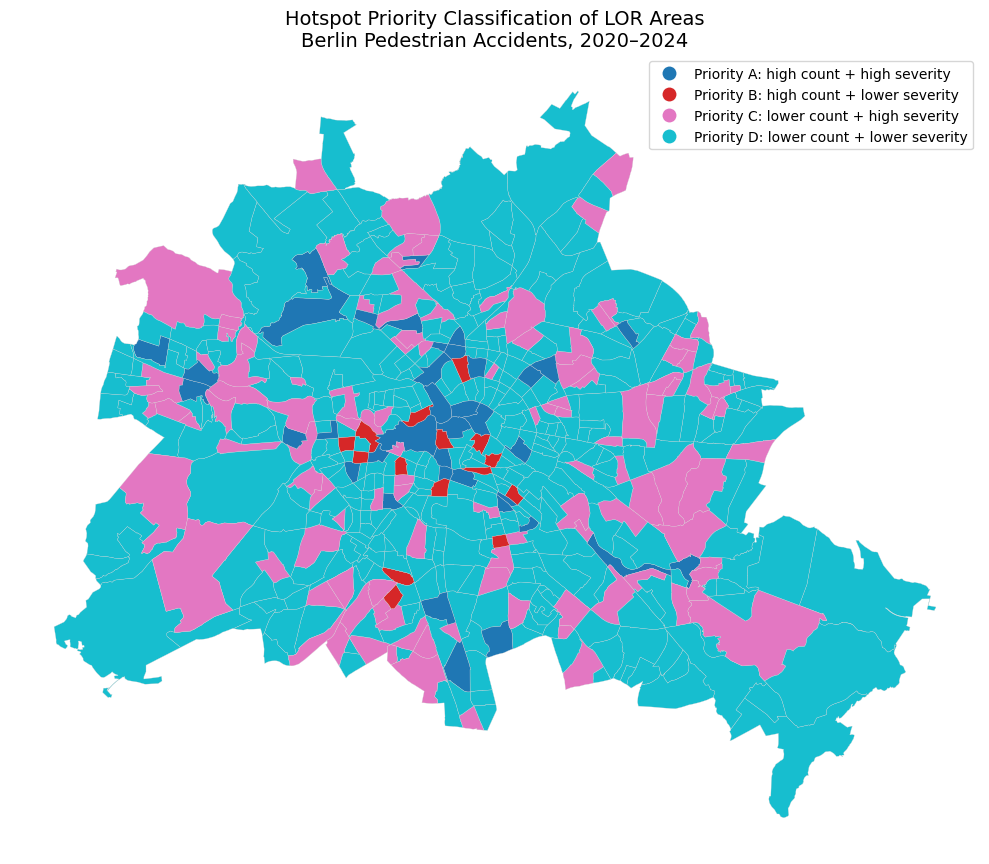

Saved map_lor_hotspot_priority_classification.png


In [ ]:
fig, ax = plt.subplots(figsize=(10, 10))

priority_df.plot(
    column='priority_class',
    categorical=True,
    legend=True,
    ax=ax,
    edgecolor='lightgrey',
    linewidth=0.2,
    missing_kwds={
        "color": "lightgrey",
        "label": "Missing data"
    }
)

ax.set_title(
    'Hotspot Priority Classification of LOR Areas\nBerlin Pedestrian Accidents, 2020–2024',
    fontsize=14
)

ax.set_axis_off()
plt.tight_layout()
plt.savefig('map_lor_hotspot_priority_classification.png', dpi=150)
plt.show()

print("Saved map_lor_hotspot_priority_classification.png")

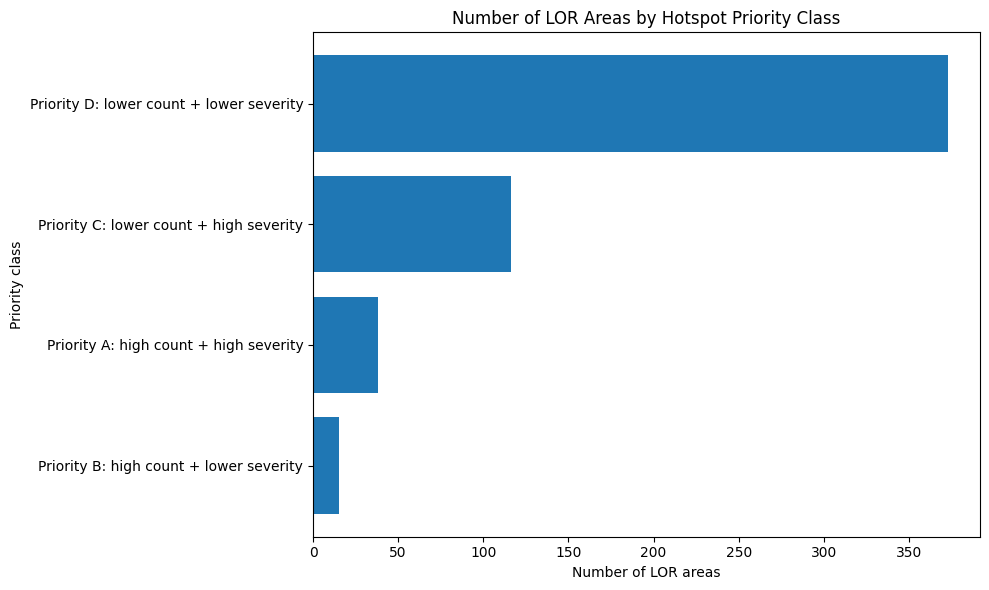

Saved chart_lor_priority_class_counts.png


In [ ]:
priority_order = [
    'Priority A: high count + high severity',
    'Priority B: high count + lower severity',
    'Priority C: lower count + high severity',
    'Priority D: lower count + lower severity'
]

plot_data = (
    priority_df['priority_class']
    .value_counts()
    .reindex(priority_order)
    .fillna(0)
    .sort_values(ascending=True)
)

plt.figure(figsize=(10, 6))
plt.barh(plot_data.index, plot_data.values)

plt.xlabel('Number of LOR areas')
plt.ylabel('Priority class')
plt.title('Number of LOR Areas by Hotspot Priority Class')
plt.tight_layout()
plt.savefig('chart_lor_priority_class_counts.png', dpi=150)
plt.show()

print("Saved chart_lor_priority_class_counts.png")

In [ ]:
priority_df.to_file(
    'lor_hotspot_priority_classification.geojson',
    driver='GeoJSON'
)

priority_df.drop(columns='geometry').to_csv(
    'lor_hotspot_priority_classification.csv',
    index=False
)

print("Saved lor_hotspot_priority_classification.geojson")
print("Saved lor_hotspot_priority_classification.csv")

Saved lor_hotspot_priority_classification.geojson
Saved lor_hotspot_priority_classification.csv
